
# To start
1. download the dataset: https://topbrain2025.grand-challenge.org/data/
2. store the dataset in your google drive folder  `CSE291G`, inside the folder you should have two folders
`labelsTr_topbrain_ct/topcow_ct_001_0000.nii.gz"`
and
`imagesTr_topbrain_ct/topcow_ct_001.nii.gz"`
3. then select GPU in google colab under `notebook setting`




#<font color="red"> **The following code is applied to 1 single patient CTA. But we can reuse this code later as python file to process all 29 patient in registration pipeline**</font>


DiffDRR: https://github.com/eigenvivek/DiffDRR
paper: https://arxiv.org/pdf/2208.12737


DiffPose:  https://github.com/eigenvivek/DiffPose


It does these steps:

1. Load the **CTA image** and **multiclass vessel label map**
2. Understand label IDs present in the case
3. <font color="red"> Keep only the **healthy hemisphere** THIS PART IS UNSURE PLEASE CHECK THE CODE</font>
4. Build controlled perturbations:
   - **Q1**: image noise after 2D projection
   - **Q2**: random vessel-volume loss
   - **Q3**: removal of proximal / medium / distal vessel groups
5. Generate a **projection-based pseudo-DSA** for debugging the pipeline
6. Save outputs for later registration experiments

## Files used

- `topcow_ct_001_0000.nii.gz` → CTA image volume
- `topcow_ct_001.nii.gz` → vessel label map


In [1]:

# Uncomment once if needed
# %pip install nibabel matplotlib scipy pandas


In [2]:
# Unmount Google Drive
from google.colab import drive
drive.flush_and_unmount()
print('Drive unmounted.')

Drive not mounted, so nothing to flush and unmount.
Drive unmounted.


In [3]:
# Re-mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive re-mounted.')

Mounted at /content/drive
Drive re-mounted.


In [4]:

from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, rotate, shift, zoom
from scipy.optimize import minimize

In [5]:
label_path = Path('/content/drive/MyDrive/CSE291G/labelsTr_topbrain_ct/')
input_path = Path('/content/drive/MyDrive/CSE291G/imagesTr_topbrain_ct/')
output_path = Path('/content/drive/MyDrive/CSE291G/output/')
CT_PATH = input_path / 'topcow_ct_001_0000.nii'
LABEL_PATH = label_path / 'topcow_ct_001.nii'
OUT_DIR = output_path/'cse291_project_outputs_complete'
OUT_DIR.mkdir(exist_ok=True, parents=True)

print('CT_PATH   =', CT_PATH)
print('LABEL_PATH=', LABEL_PATH)
print('OUT_DIR   =', OUT_DIR)


CT_PATH   = /content/drive/MyDrive/CSE291G/imagesTr_topbrain_ct/topcow_ct_001_0000.nii
LABEL_PATH= /content/drive/MyDrive/CSE291G/labelsTr_topbrain_ct/topcow_ct_001.nii
OUT_DIR   = /content/drive/MyDrive/CSE291G/output/cse291_project_outputs_complete


## Load the image and label map

In [6]:
from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
import nibabel as nib
import numpy as np

CT_PATH = "/content/drive/MyDrive/CSE291G/imagesTr_topbrain_ct/topcow_ct_001_0000.nii.gz"
LABEL_PATH = "/content/drive/MyDrive/CSE291G/labelsTr_topbrain_ct/topcow_ct_001.nii.gz"

# NifTi objects contain image data + metadata, metadata includes
# voxel spacing, coordinate system, orientation, scanner info
ct_img = nib.load(CT_PATH)
label_img = nib.load(LABEL_PATH)

# convert ct to numpy arrays
# eg. ct[x,y,z] = 285
ct = ct_img.get_fdata().astype(np.float32)
# labels[x,y,z]=12
# meaning: voxel belongs to vessel type 12
labels = label_img.get_fdata().astype(np.int16)

# convert voxel coordinates to physical coordinates
# eg. voxel (100,120,80) --> real world location (mm)
# might be useful for registration later

# Typical CT Affine Characteristics
# Diagonal elements: Usually [-voxel_size_x, voxel_size_y, voxel_size_z, 1] — the negative sign in X is common due to radiological coordinate conventions.
# Translation terms: Position of the first voxel in world space.
# No shear: Off-diagonal spatial terms are usually zero in CT.
affine = ct_img.affine
# e.g., voxel size in millimeters (0.5, 0.5, 0.6)
# means: x voxel = 0.5 mm, y voxel = 0.5 mm, z voxel = 0.6 mm

spacing = ct_img.header.get_zooms()[:3]
# how axes are oriented, ('R','A','S')
#X increases -> Left
#Y increases -> Back of head
#Z increases -> Upward
axcodes = nib.aff2axcodes(affine)

print("CT shape in (pixels, pixels, slices):", ct.shape)
print("Label shape:", labels.shape)
print("Voxel spacing:", spacing)
print("Axis codes:", axcodes)
print("CT min / max:", float(ct.min()), float(ct.max()))
print("Unique labels:", np.unique(labels))
print("Num unique labels:", len(np.unique(labels)))

assert ct.shape == labels.shape

CT shape in (pixels, pixels, slices): (284, 327, 243)
Label shape: (284, 327, 243)
Voxel spacing: (np.float32(0.507813), np.float32(0.507813), np.float32(0.625))
Axis codes: ('L', 'P', 'S')
CT min / max: -3024.0 3071.0
Unique labels: [ 0  1  2  3  4  5  8 11 12 13 14 17 18 21 22 23 24 25 26 27 29 30 33 35
 36 37 38 39 40]
Num unique labels: 29


- ct[x,y,z]
- x = left-right
- y = front-back
- z = slice index
- to get one slice: slice = ct[:,:,z]

*  the scan is anisotropic (Z resolution is slightly lower)


*  the scan covers roughly 14-16 cm of brain volume
*   the axis orientation is X axis -> left, Y axis -> posterior, Z axis-> superior

- what it means if X increases, then left shifts, Y increases, back of head, Z increases upward

- **In left right hemisphere occlusion to keep only the healthy hemisphere, we need to split along Axis = 0**



- CT intensity range: Hounsfield units (HU)
eg.
```
Air        ≈ -1000
Fat        ≈ -100
Water      = 0
Brain      ≈ 20–40
Bone       ≈ 1000+
Contrast   ≈ 200–500
```
In our dataset:
```
-3024 -> outside scan / padding
3071  -> very dense tissue
```

- Labels: 40 labels, 0 is background. More detailed info in the next cell


```
# This is formatted as code
```






## Label dictionary for TopBrain CTA

The dataset page says the TopBrain CTA labels include 40 classes, with labels 1–12 and 15 inherited from TopCoW.

<font color="purple"> **updated `TOPBRAIN_CTA_LABELS` since the previous one does not match the label order in `itksnap_labelmap_txt\labelmap_topbrain_ct.txt` provided in the dataset**</font>


In [7]:

# TOPBRAIN_CTA_LABELS = {
#     0: 'background',
#     1: 'BA',
#     2: 'R-P1P2',
#     3: 'L-P1P2',
#     4: 'R-ICA',
#     5: 'R-M1',
#     6: 'L-ICA',
#     7: 'L-M1',
#     8: 'R-Pcom',
#     9: 'L-Pcom',
#     10: 'Acom',
#     11: 'R-A1A2',
#     12: 'L-A1A2',
#     13: '3rd-A2',
#     14: 'R-A3',
#     15: 'L-A3',
#     # The exact TopBrain page contains additional distal / cerebellar / venous labels.
#     # For the project grouping below, we mainly need clinically meaningful proximal/medium/distal bins.
#     16: 'R-M2M3',
#     17: 'L-M2M3',
#     18: 'R-M4',
#     19: 'L-M4',
#     20: 'R-P3P4',
#     21: 'L-P3P4',
#     22: 'R-VA',
#     23: 'L-VA',
#     24: 'R-SCA',
#     25: 'L-SCA',
#     26: 'R-AICA',
#     27: 'L-AICA',
#     28: 'R-PICA',
#     29: 'L-PICA',
#     30: 'R-AChA',
#     31: 'L-AChA',
#     32: 'R-OA',
#     33: 'L-OA',
#     34: 'VoG',
#     35: 'StS',
#     36: 'R-TS',
#     37: 'L-TS',
#     38: 'R-SigS',
#     39: 'L-SigS',
#     40: 'SSS',
# }

TOPBRAIN_CTA_LABELS = {
    0: 'background',

    # Basilar / posterior circulation
    1: 'BA',
    2: 'R-P1P2',
    3: 'L-P1P2',

    # ICA + proximal MCA
    4: 'R-ICA',
    5: 'R-M1',
    6: 'L-ICA',
    7: 'L-M1',

    # communicating arteries
    8: 'R-Pcom',
    9: 'L-Pcom',
    10: 'Acom',

    # ACA
    11: 'R-A1A2',
    12: 'L-A1A2',
    13: 'R-A3',
    14: 'L-A3',
    15: '3rd-A2',
    16: '3rd-A3',

    # MCA distal
    17: 'R-M2',
    18: 'R-M3',
    19: 'L-M2',
    20: 'L-M3',

    # PCA distal
    21: 'R-P3P4',
    22: 'L-P3P4',

    # vertebral
    23: 'R-VA',
    24: 'L-VA',

    # cerebellar arteries
    25: 'R-SCA',
    26: 'L-SCA',
    27: 'R-AICA',
    28: 'L-AICA',
    29: 'R-PICA',
    30: 'L-PICA',

    # small branches
    31: 'R-AChA',
    32: 'L-AChA',
    33: 'R-OA',
    34: 'L-OA',

    # venous structures
    35: 'VoG',
    36: 'StS',
    37: 'ICVs',
    38: 'R-BVR',
    39: 'L-BVR',
    40: 'SSS'
}

unique_labels = np.unique(labels)
label_table = pd.DataFrame({
    'label_id': unique_labels,
    'name': [TOPBRAIN_CTA_LABELS.get(int(x), f'unknown_{int(x)}') for x in unique_labels],
    'voxel_count': [int((labels == x).sum()) for x in unique_labels],
}).sort_values('label_id').reset_index(drop=True)

assert label_table.voxel_count.sum() == np.prod(ct.shape)

label_table


,label_id,name,voxel_count
0,0,background,22487747
1,1,BA,2975
2,2,R-P1P2,1705
3,3,L-P1P2,1940
4,4,R-ICA,2444
5,5,R-M1,1075
6,8,R-Pcom,218
7,11,R-A1A2,1704
8,12,L-A1A2,1561
9,13,R-A3,769


## Quick visualization
- visualize one 2D slice from 3D volume and display it with matplot. Show both original CT and its vessel labels
- volume: 3D numpy array (CT or label map)
- axis: which direction to slice
- index: which slice number
- cmap: color map
- vmin, vmax: intensity range

axis meanings and anatomical direction
- axis 0: left <-> right
- axis 1: front <-> back
- axis 2: bottom <-> top

<font color="purple">(optional) the labels have their colors in the given dataset, we may consider to use them instead of `cmap` </font>

axis 2: axial slice, looking from above the head downward


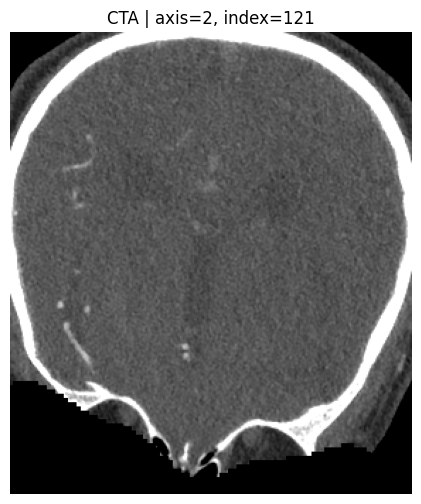

vessels label, each vessel ID gest a different color


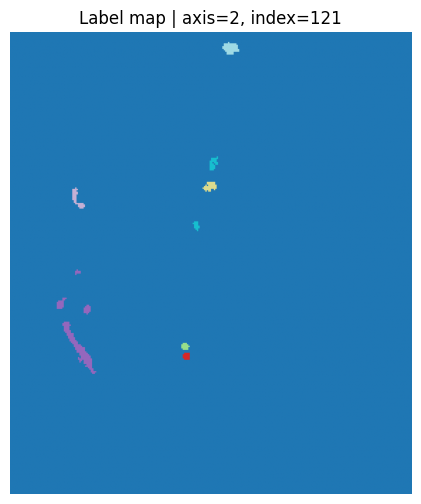

In [8]:

def show_slice(volume, axis=2, index=None, title='', cmap='gray', vmin=None, vmax=None):
    if index is None:
        index = volume.shape[axis] // 2
    if axis == 0:
        img = volume[index, :, :]
    elif axis == 1:
        img = volume[:, index, :]
    else:
        img = volume[:, :, index]
    plt.figure(figsize=(6, 6))
    plt.imshow(img.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    plt.title(f'{title} | axis={axis}, index={index}')
    plt.axis('off')
    plt.show()


print("axis 2: axial slice, looking from above the head downward")
show_slice(ct, axis=2, title='CTA', vmin=-200, vmax=500)
print("vessels label, each vessel ID gest a different color")
show_slice(labels, axis=2, title='Label map', cmap='tab20')


axis 1: axial slice


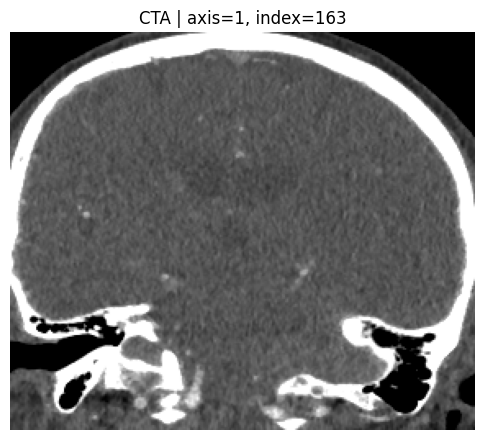

vessels label, each vessel ID gest a different color


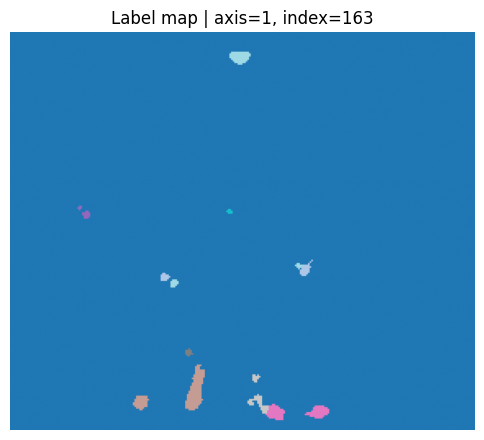

In [9]:
print("axis 1: axial slice")
show_slice(ct, axis=1, title='CTA', vmin=-200, vmax=500)
print("vessels label, each vessel ID gest a different color")
show_slice(labels, axis=1, title='Label map', cmap='tab20')

axis 1: axial slice


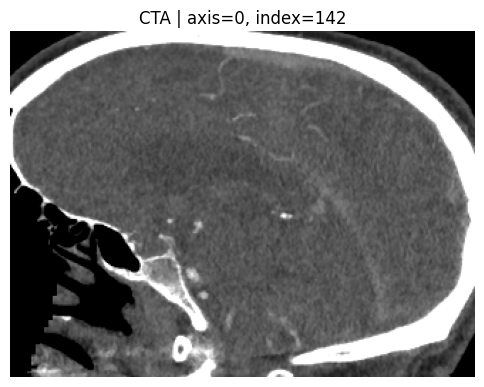

vessels label, each vessel ID gest a different color


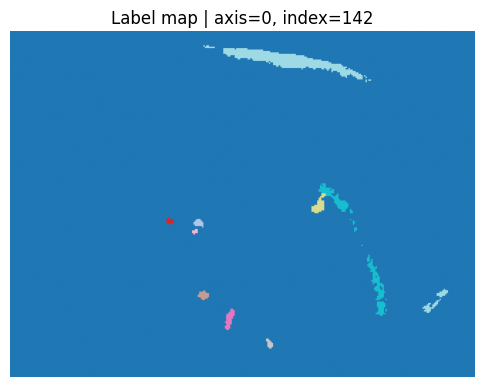

In [10]:
print("axis 1: axial slice")
show_slice(ct, axis=0, title='CTA', vmin=-200, vmax=500)
print("vessels label, each vessel ID gest a different color")
show_slice(labels, axis=0, title='Label map', cmap='tab20')

#<font color="red"> **Question: I realized that we do not know about WHAT EXACTLY IS THE HEALTHY Hemisphere, the function is still here, but we might need to think about whether we want to remove another half**

<font color="purple"> **maybe if we don't have that info, we can rename the "healthy hemisphere" as "selected hemisphere" or run both hemispheres and report both**



## Hemisphere selection that respects orientation

The Zenodo release says CTA images are stored in **LPS+ orientation**.
Still, instead of assuming the first half of axis 0 is always one side, we derive the **left-right axis** from the affine.


In [11]:

def get_left_right_axis_and_direction(affine):
    axcodes = nib.aff2axcodes(affine)
    # Find which axis corresponds to Left/Right.
    for axis, code in enumerate(axcodes):
        if code in ('L', 'R'):
            return axis, code
    raise ValueError(f'Could not find a left-right axis from affine. axcodes={axcodes}')


def keep_single_hemisphere(volume, affine, keep_side='right'):
    """
    Keep only one hemisphere using the affine-derived left-right axis.

    keep_side='right' means keep anatomical right, regardless of array storage direction.
    """
    lr_axis, positive_dir = get_left_right_axis_and_direction(affine)
    out = np.zeros_like(volume)
    n = volume.shape[lr_axis]
    mid = n // 2

    slicer_low = [slice(None)] * 3
    slicer_high = [slice(None)] * 3
    slicer_low[lr_axis] = slice(0, mid)
    slicer_high[lr_axis] = slice(mid, n)

    # If positive axis direction is 'L', then low indices are more 'R'.
    # If positive axis direction is 'R', then high indices are more 'R'.
    if keep_side.lower() == 'right':
        src = tuple(slicer_low) if positive_dir == 'L' else tuple(slicer_high)
    elif keep_side.lower() == 'left':
        src = tuple(slicer_high) if positive_dir == 'L' else tuple(slicer_low)
    else:
        raise ValueError("keep_side must be 'right' or 'left'")

    out[src] = volume[src]
    return out

lr_axis, lr_positive = get_left_right_axis_and_direction(affine)
print('Left-right axis:', lr_axis)
print('Positive direction along that axis:', lr_positive)


Left-right axis: 0
Positive direction along that axis: L


Remaining healthy-hemisphere vessel voxels: 42346


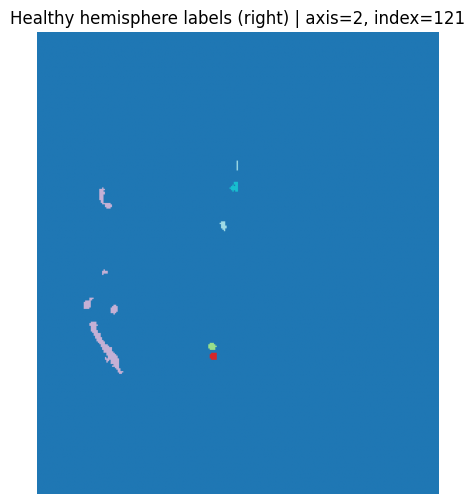

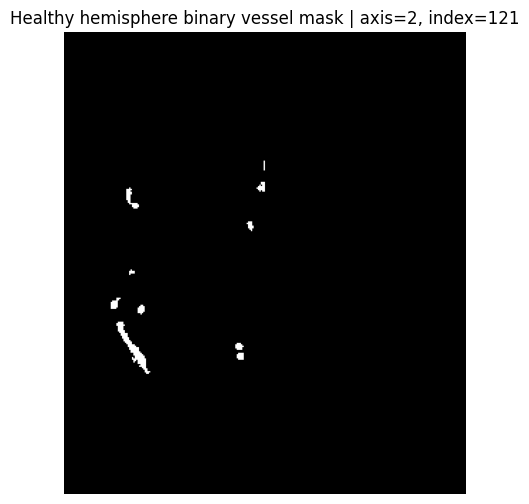

In [12]:

KEEP_SIDE = 'right'   # change to 'left' if needed

healthy_labels = keep_single_hemisphere(labels, affine, keep_side=KEEP_SIDE)
healthy_ct = keep_single_hemisphere(ct, affine, keep_side=KEEP_SIDE)
healthy_binary = (healthy_labels > 0).astype(np.uint8)

print('Remaining healthy-hemisphere vessel voxels:', int(healthy_binary.sum()))
show_slice(healthy_labels, axis=2, title=f'Healthy hemisphere labels ({KEEP_SIDE})', cmap='tab20')
show_slice(healthy_binary, axis=2, title='Healthy hemisphere binary vessel mask', cmap='gray')


Remaining healthy-hemisphere vessel voxels: 42346


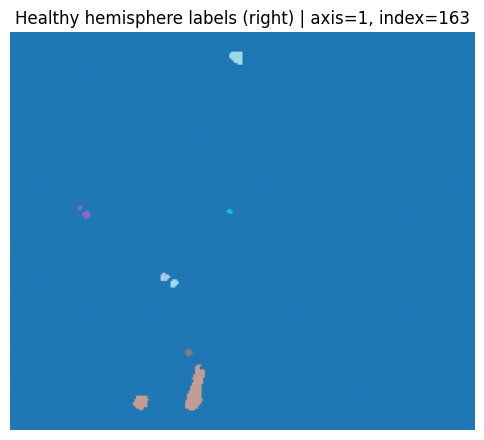

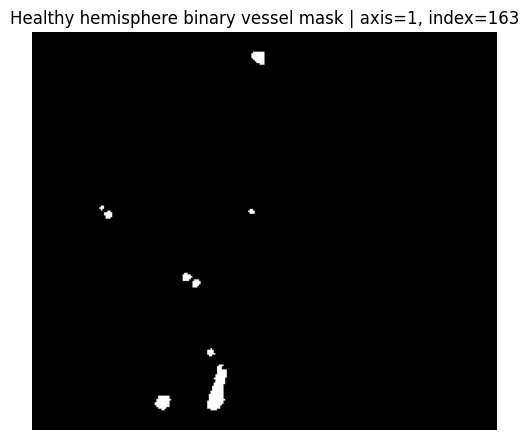

In [13]:
print('Remaining healthy-hemisphere vessel voxels:', int(healthy_binary.sum()))
show_slice(healthy_labels, axis=1, title=f'Healthy hemisphere labels ({KEEP_SIDE})', cmap='tab20')
show_slice(healthy_binary, axis=1, title='Healthy hemisphere binary vessel mask', cmap='gray')

## Helper functions

- save_nifti: This function saves a 3D volume as a .nii or .nii.gz medical image file.



In [14]:

def save_nifti(data, reference_img, out_path, dtype=None):
    arr = data.astype(dtype) if dtype is not None else data
    out_img = nib.Nifti1Image(arr, reference_img.affine, reference_img.header)
    nib.save(out_img, str(out_path))
    print('Saved:', out_path)



def save_png(image2d, out_path, cmap='gray'):
    plt.figure(figsize=(6, 6))
    plt.imshow(image2d, cmap=cmap)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight', pad_inches=0)
    plt.close()
    print('Saved:', out_path)


def normalize_01(x):
    x = x.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    if mx - mn < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn)


# Pipeline Overview


```
1. CTA_original

2. CTA_original + apply transformation T = CTA_transformed

2. vessel perturbation on CTA_transformed: vessel removal (volume and types): CTA_transformed_pertubated

3. Render DSA on CTA_transformed_pertubated: DSA_observed

DSA_observed: DSA_original, DSA_removal_volume, DSA_removal_types, DSA_original_noise

4.
CTA_transformed
↓
CTA_moving

CTA_moving + DSA_observed and T
↓
DiffPose registration
↓
recover pose T
↓
compute mTRE

```



## Q2 — random vessel-volume loss

In [15]:

def remove_random_vessel_volume(binary_mask, removal_fraction, seed=0):
    """
    Randomly zero out a percentage of vessel voxels.
    removal_fraction in [0, 1].
    """
    if not (0.0 <= removal_fraction <= 1.0):
        raise ValueError('removal_fraction must be between 0 and 1')

    rng = np.random.default_rng(seed)
    out = binary_mask.copy()
    vessel_idx = np.argwhere(out > 0)
    n_remove = int(len(vessel_idx) * removal_fraction)

    if n_remove > 0:
        chosen = rng.choice(len(vessel_idx), size=n_remove, replace=False)
        voxels = vessel_idx[chosen]
        out[voxels[:, 0], voxels[:, 1], voxels[:, 2]] = 0
    return out

VOLUME_LOSS_LEVELS = [0.00, 0.10, 0.25, 0.50, 1.00]
q2_masks = {frac: remove_random_vessel_volume(healthy_binary, frac, seed=42) for frac in VOLUME_LOSS_LEVELS}

for frac, mask in q2_masks.items():
    print(f'removal={frac:.0%} | remaining voxels={int(mask.sum())}')


removal=0% | remaining voxels=42346
removal=10% | remaining voxels=38112
removal=25% | remaining voxels=31760
removal=50% | remaining voxels=21173
removal=100% | remaining voxels=0


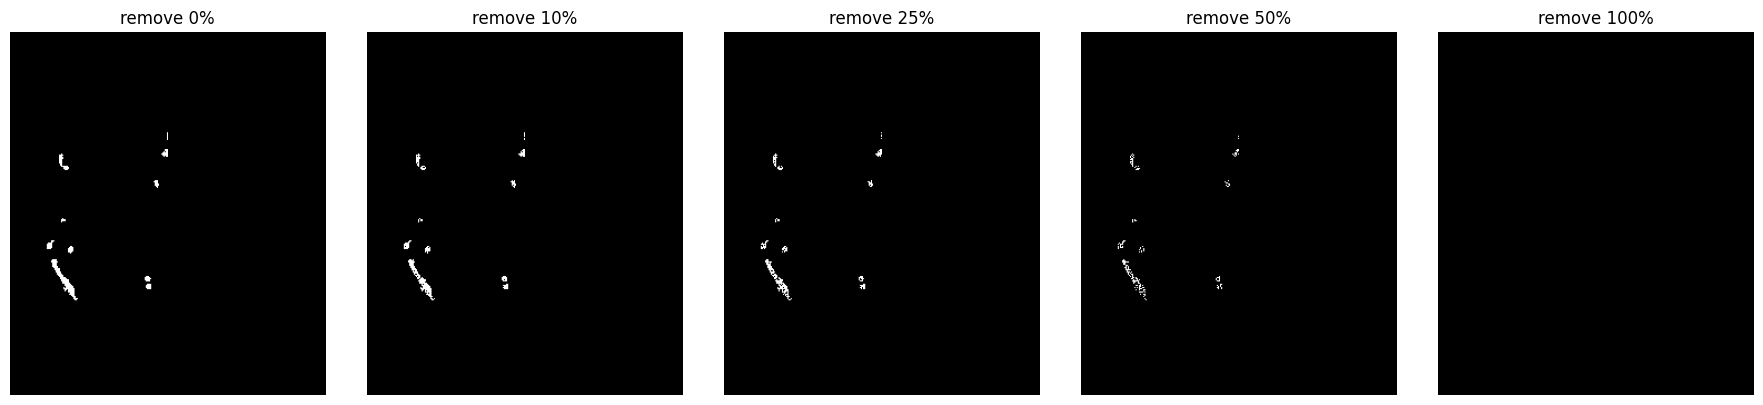

In [16]:

fig, axes = plt.subplots(1, len(VOLUME_LOSS_LEVELS), figsize=(18, 4))
for ax, frac in zip(axes, VOLUME_LOSS_LEVELS):
    img = q2_masks[frac][:, :, q2_masks[frac].shape[2] // 2].T
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(f'remove {frac:.0%}')
    ax.axis('off')
plt.tight_layout()
plt.show()



## Q3 — vessel-group removal

defines three groups:

- **proximal / large**: ICA, BA, VA
- **medium**: M1, A1/A2, P1/P2
- **distal**: M2/M3, A3, P3/P4, 3rd-A3

Below, the groups are written in terms of TopBrain CTA label IDs.
The code automatically ignores IDs that are not present in this specific case.


In [17]:

# VESSEL_GROUPS = {
#     'proximal': [1, 4, 6, 22, 23],      # BA, R/L ICA, R/L VA
#     'medium':   [2, 3, 5, 7, 11, 12],   # P1P2, M1, A1A2
#     'distal':   [13, 14, 15, 16, 17, 18, 20, 21],  # 3rd-A2, A3, M2M3/M4, P3P4
# }

#3rd-A2, 3rd-A3

VESSEL_GROUPS = {
    'proximal': [1, 4, 6, 23, 24],      # BA, R/L ICA, R/L VA
    'medium':   [2, 3, 5, 7, 11, 12],   # P1P2, M1, A1A2
    'distal':   [17, 19, 18, 20, 13, 14, 16],  # R/L M2, R/L-M3, R/L-A3, R/L-P3P4,3rd-A3
}


def get_present_group_ids(group_ids, label_map):
    present = set(np.unique(label_map).tolist())
    return [x for x in group_ids if x in present]


def remove_label_group(label_map, group_ids):
    out = label_map.copy()
    present_ids = get_present_group_ids(group_ids, label_map)
    out[np.isin(out, present_ids)] = 0
    return out, present_ids

q3_label_maps = {'baseline': healthy_labels.copy()}
q3_removed_present_ids = {'baseline': []}

for group_name, group_ids in VESSEL_GROUPS.items():
    new_map, present_ids = remove_label_group(healthy_labels, group_ids)
    q3_label_maps[group_name] = new_map
    q3_removed_present_ids[group_name] = present_ids

q3_binary_masks = {k: (v > 0).astype(np.uint8) for k, v in q3_label_maps.items()}

for name in q3_binary_masks:
    print(name, '| removed present IDs =', q3_removed_present_ids[name], '| remaining voxels =', int(q3_binary_masks[name].sum()))


baseline | removed present IDs = [] | remaining voxels = 42346
proximal | removed present IDs = [1, 4, 23, 24] | remaining voxels = 30088
medium | removed present IDs = [2, 3, 5, 11, 12] | remaining voxels = 36483
distal | removed present IDs = [17, 18, 13, 14] | remaining voxels = 30205


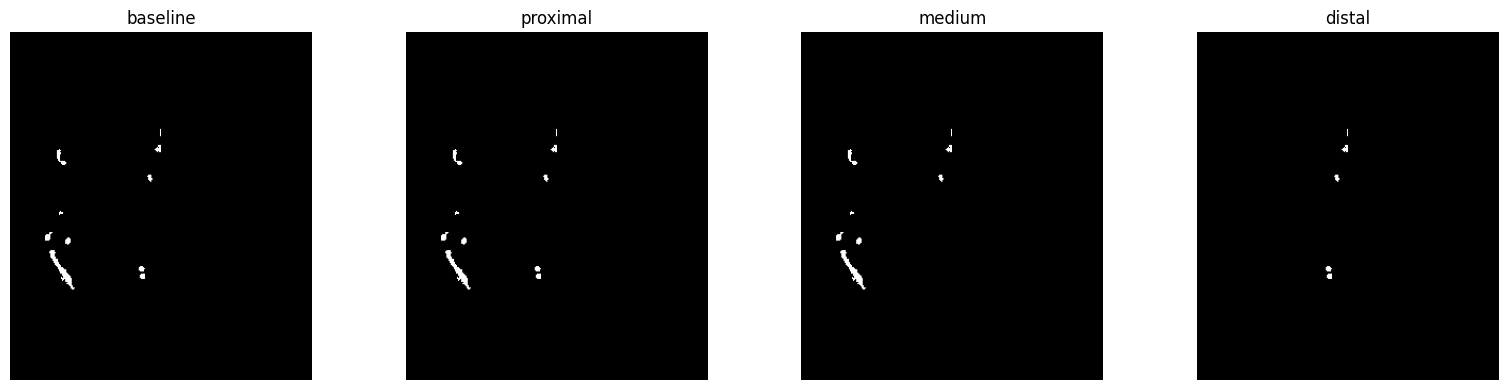

In [18]:

fig, axes = plt.subplots(1, len(q3_binary_masks), figsize=(4 * len(q3_binary_masks), 4))
if len(q3_binary_masks) == 1:
    axes = [axes]
for ax, (name, mask) in zip(axes, q3_binary_masks.items()):
    img = mask[:, :, mask.shape[2] // 2].T
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [19]:

def add_gaussian_noise(image, sigma=0.03, seed=0):
    rng = np.random.default_rng(seed)
    noisy = image + rng.normal(0.0, sigma, size=image.shape)
    return np.clip(noisy, 0.0, 1.0)

def add_poisson_noise(image, peak=40, seed=0):
    rng = np.random.default_rng(seed)
    scaled = np.clip(image, 0.0, 1.0) * peak
    noisy = rng.poisson(scaled) / float(peak)
    return np.clip(noisy, 0.0, 1.0)



# Benchmark logic

For each scenario:

- the **observed DSA** is rendered from the scenario anatomy (baseline / Q2 / Q3) at the ground-truth pose `T_gt`
- the **moving model** used by registration remains the **original healthy model**
- pose optimization tries to recover `T_gt`

implement the transform as a **renderer pose** rather than physically storing `CTA_transform = T · CTA`.

In [20]:

def sample_random_rigid_params(seed=0,
                               tx_range_mm=(-5, 5),
                               ty_range_mm=(-5, 5),
                               tz_range_mm=(-5, 5),
                               rx_range_deg=(-5, 5),
                               ry_range_deg=(-5, 5),
                               rz_range_deg=(-5, 5)):
    rng = np.random.default_rng(seed)
    return np.array([
        float(rng.uniform(*rx_range_deg)),
        float(rng.uniform(*ry_range_deg)),
        float(rng.uniform(*rz_range_deg)),
        float(rng.uniform(*tx_range_mm)),
        float(rng.uniform(*ty_range_mm)),
        float(rng.uniform(*tz_range_mm)),
    ], dtype=np.float32)

T_gt = sample_random_rigid_params(seed=42)
print("T_gt [rx, ry, rz, tx, ty, tz] =", T_gt)

T_gt [rx, ry, rz, tx, ty, tz] = [ 2.7395606 -0.6112156  3.5859792  1.9736803 -4.0582266  4.7562237]


In [21]:

def maybe_downsample_volume(volume, factor):
    if factor == 1.0:
        return volume.astype(np.float32)
    return zoom(volume.astype(np.float32), zoom=(factor, factor, factor), order=0)


DOWNSAMPLE_FACTOR = 0.5  # speeds up registration rendering; set to 1.0 for full size
healthy_binary_ds = maybe_downsample_volume(healthy_binary, DOWNSAMPLE_FACTOR)
q2_masks_ds = {k: maybe_downsample_volume(v, DOWNSAMPLE_FACTOR) for k, v in q2_masks.items()}
q3_masks_ds = {k: maybe_downsample_volume(v, DOWNSAMPLE_FACTOR) for k, v in q3_binary_masks.items()}
spacing_ds = tuple(s / DOWNSAMPLE_FACTOR for s in spacing)

print("Downsampled healthy shape:", healthy_binary_ds.shape)
print("Downsampled spacing:", spacing_ds)

Downsampled healthy shape: (142, 164, 122)
Downsampled spacing: (np.float32(1.015626), np.float32(1.015626), np.float32(1.25))


## Apply ground truth projection T to the modified CTA

In [22]:

def apply_rigid_transform_volume(volume, rx_deg=0.0, ry_deg=0.0, rz_deg=0.0,
                                 tx_mm=0.0, ty_mm=0.0, tz_mm=0.0,
                                 spacing=(1.0, 1.0, 1.0), order=1):
    vol = volume.astype(np.float32)

    # Rotations around x, y, z using array axes conventions.
    if abs(rx_deg) > 1e-8:
        vol = rotate(vol, angle=rx_deg, axes=(1, 2), reshape=False, order=order, mode="constant", cval=0.0)
    if abs(ry_deg) > 1e-8:
        vol = rotate(vol, angle=ry_deg, axes=(0, 2), reshape=False, order=order, mode="constant", cval=0.0)
    if abs(rz_deg) > 1e-8:
        vol = rotate(vol, angle=rz_deg, axes=(0, 1), reshape=False, order=order, mode="constant", cval=0.0)

    # Convert mm translations into voxel shifts.
    shift_vox = (
        tx_mm / spacing[0],
        ty_mm / spacing[1],
        tz_mm / spacing[2],
    )
    if max(abs(s) for s in shift_vox) > 1e-8:
        vol = shift(vol, shift=shift_vox, order=order, mode="constant", cval=0.0)

    return vol




## Render DSA

For now we use a **simple projection placeholder** so the perturbation pipeline is correct and easy to debug. don't use diffdrr


# **<font color='red'> DiffDRR did not work well in our setting because it simulates realistic X-ray physics and expects a full CT attenuation volume containing tissue, bone, and contrast values. Our data, consists only of binary vessel masks where voxels are either vessel or background. Since vessels occupy only a small number of voxels along each X-ray path, the accumulated attenuation is extremely small, which results in very low image contrast and nearly blank projections. </font>**




In [23]:
def pseudo_dsa_from_volume_at_pose(binary_or_soft_volume, pose_params,
                                   proj_axis=0, blur_sigma=1.0, spacing=(1.0,1.0,1.0)):
    rx_deg, ry_deg, rz_deg, tx_mm, ty_mm, tz_mm = pose_params
    moved = apply_rigid_transform_volume(
        binary_or_soft_volume,
        rx_deg=rx_deg, ry_deg=ry_deg, rz_deg=rz_deg,
        tx_mm=tx_mm, ty_mm=ty_mm, tz_mm=tz_mm,
        spacing=spacing, order=1
    )
    moved = gaussian_filter(moved.astype(np.float32), sigma=blur_sigma)
    proj = moved.sum(axis=proj_axis)
    return normalize_01(proj)

## Create observed DSA images at the same ground-truth pose

This is the corrected benchmark construction:

- **baseline observed DSA** comes from the healthy anatomy at `T_gt`
- **Q2 observed DSA** comes from the volume-loss anatomy at `T_gt`
- **Q3 observed DSA** comes from the group-removed anatomy at `T_gt`
- **Q1** adds noise **after projection**

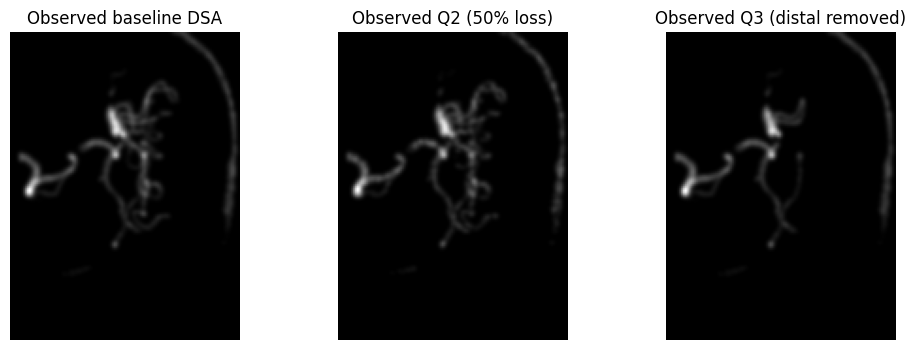

In [24]:

PROJ_AXIS = 0         # projection axis for pseudo-DSA

baseline_dsa_obs = pseudo_dsa_from_volume_at_pose(
    healthy_binary_ds, T_gt, proj_axis=PROJ_AXIS, blur_sigma=1.0, spacing=spacing_ds
)

GAUSSIAN_SIGMAS = [0.00, 0.01, 0.03, 0.05, 0.10]
POISSON_PEAKS = [20, 40, 80]

q1_gaussian_dsas = {sigma: add_gaussian_noise(baseline_dsa_obs, sigma=sigma, seed=42) for sigma in GAUSSIAN_SIGMAS}
q1_poisson_dsas = {peak: add_poisson_noise(baseline_dsa_obs, peak=peak, seed=42) for peak in POISSON_PEAKS}

q2_dsas_obs = {
    frac: pseudo_dsa_from_volume_at_pose(mask, T_gt, proj_axis=PROJ_AXIS, blur_sigma=1.0, spacing=spacing_ds)
    for frac, mask in q2_masks_ds.items()
}

q3_dsas_obs = {
    name: pseudo_dsa_from_volume_at_pose(mask, T_gt, proj_axis=PROJ_AXIS, blur_sigma=1.0, spacing=spacing_ds)
    for name, mask in q3_masks_ds.items()
}

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(baseline_dsa_obs, cmap="gray")
plt.title("Observed baseline DSA")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(q2_dsas_obs[0.50], cmap="gray")
plt.title("Observed Q2 (50% loss)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(q3_dsas_obs["distal"], cmap="gray")
plt.title("Observed Q3 (distal removed)")
plt.axis("off")
plt.show()

# Registration with DiffPose-Style Optimization

Replace the Powell optimizer with **gradient-based optimization** following the DiffPose approach:
- Use PyTorch for differentiable rendering simulation
- Adam optimizer with separate learning rates for rotation and translation
- Multiscale NCC loss (local + global)
- Learning rate decay for stable convergence

**Reference:** [DiffPose (CVPR 2024)](https://arxiv.org/abs/2312.06358)

**<font color='purple'> Right now the code is a simplified numerical-gradient NCC baseline, not a differentiable DiffPose-style pipeline. </font>**


In [25]:
# =============================================================================
# TPU Setup (Run this cell ONLY if using TPU runtime)
# =============================================================================
# If you're using GPU, skip this cell!
#
# For TPU in Colab:
# 1. Runtime -> Change runtime type -> TPU
# 2. Run this cell to install torch_xla

# Uncomment the lines below if using TPU:

# !pip install cloud-tpu-client==0.10 torch==2.0.0 torchvision==0.15.1 https://storage.googleapis.com/tpu-pytorch/wheels/colab/torch_xla-2.0-cp310-cp310-linux_x86_64.whl

# import torch_xla
# import torch_xla.core.xla_model as xm
# print(f"TPU available: {xm.xla_device()}")

print("TPU setup cell - uncomment lines above if using TPU runtime")
print("For GPU: Just make sure you selected GPU in Runtime settings")

TPU setup cell - uncomment lines above if using TPU runtime
For GPU: Just make sure you selected GPU in Runtime settings


In [26]:
import torch
from tqdm import tqdm
from scipy.ndimage import rotate, shift, gaussian_filter

# =============================================================================
# Device Setup
# =============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =============================================================================
# Use the EXACT SAME rendering as your original pseudo_dsa_from_volume_at_pose
# =============================================================================
# This ensures the optimization target matches the observed image exactly.

def render_at_pose(volume, pose_params, spacing, proj_axis=0, blur_sigma=1.0):
    """
    Render pseudo-DSA at given pose - IDENTICAL to pseudo_dsa_from_volume_at_pose.
    """
    rx_deg, ry_deg, rz_deg, tx_mm, ty_mm, tz_mm = pose_params

    vol = volume.astype(np.float32).copy()

    # Rotations (same axes convention as scipy.ndimage.rotate)
    if abs(rx_deg) > 1e-8:
        vol = rotate(vol, angle=rx_deg, axes=(1, 2), reshape=False, order=1, mode="constant", cval=0.0)
    if abs(ry_deg) > 1e-8:
        vol = rotate(vol, angle=ry_deg, axes=(0, 2), reshape=False, order=1, mode="constant", cval=0.0)
    if abs(rz_deg) > 1e-8:
        vol = rotate(vol, angle=rz_deg, axes=(0, 1), reshape=False, order=1, mode="constant", cval=0.0)

    # Translation (mm to voxels)
    shift_vox = (
        tx_mm / spacing[0],
        ty_mm / spacing[1],
        tz_mm / spacing[2],
    )
    if max(abs(s) for s in shift_vox) > 1e-8:
        vol = shift(vol, shift=shift_vox, order=1, mode="constant", cval=0.0)

    # Blur
    vol = gaussian_filter(vol, sigma=blur_sigma)

    # Project
    proj = vol.sum(axis=proj_axis)

    # Normalize
    pmin, pmax = proj.min(), proj.max()
    if pmax - pmin > 1e-8:
        proj = (proj - pmin) / (pmax - pmin)
    else:
        proj = np.zeros_like(proj)

    return proj.astype(np.float32)


def ncc_numpy(a, b, eps=1e-8):
    """Normalized Cross-Correlation (numpy)."""
    a = a.astype(np.float64).flatten()
    b = b.astype(np.float64).flatten()
    a = a - a.mean()
    b = b - b.mean()
    denom = np.sqrt((a*a).sum() * (b*b).sum()) + eps
    return float((a*b).sum() / denom)

#Q1: compare MI and masked NCC under degraded images.
def masked_ncc_numpy(a, b, mask=None, eps=1e-8):
    if mask is None:
        mask = np.ones_like(a, dtype=bool)
    av = a[mask].astype(np.float64)
    bv = b[mask].astype(np.float64)
    av = av - av.mean()
    bv = bv - bv.mean()
    denom = np.sqrt((av * av).sum() * (bv * bv).sum()) + eps
    return float((av * bv).sum() / denom)


# =============================================================================
# Gradient-Based Optimization with Numerical Gradients
# =============================================================================

# def compute_numerical_gradient(volume, current_params, observed, spacing, proj_axis,
#                                 eps_rot=0.1, eps_trans=0.1):
#     """
#     Compute gradient using finite differences.
#     This guarantees we use the exact same rendering as the target.
#     """
#     grad = np.zeros(6, dtype=np.float64)
#     base_ncc = ncc_numpy(render_at_pose(volume, current_params, spacing, proj_axis), observed)

#     for i in range(6):
#         params_plus = current_params.copy()
#         eps = eps_rot if i < 3 else eps_trans
#         params_plus[i] += eps

#         ncc_plus = ncc_numpy(render_at_pose(volume, params_plus, spacing, proj_axis), observed)
#         grad[i] = (ncc_plus - base_ncc) / eps

#     return grad, base_ncc


# def run_diffpose_registration(
#     moving_volume,
#     observed_dsa,
#     init_params=None,
#     spacing=(1.0, 1.0, 1.0),
#     proj_axis=0,
#     n_iters=150,
#     lr_rot=0.3,
#     lr_trans=0.5,
#     momentum=0.9,
#     verbose=True,
# ):
#     """
#     Gradient-based registration using numerical gradients.

#     Uses the EXACT same rendering as pseudo_dsa_from_volume_at_pose,
#     with gradient ascent on NCC.
#     """
#     if init_params is None:
#         init_params = np.zeros(6, dtype=np.float32)

#     params = init_params.copy().astype(np.float64)
#     velocity = np.zeros(6, dtype=np.float64)

#     best_ncc = -float('inf')
#     best_params = params.copy()
#     ncc_history = []

#     # Learning rates: [rot, rot, rot, trans, trans, trans]
#     lrs = np.array([lr_rot, lr_rot, lr_rot, lr_trans, lr_trans, lr_trans], dtype=np.float64)

#     iterator = tqdm(range(n_iters), desc="DiffPose", disable=not verbose)

#     for i in iterator:
#         # Compute gradient
#         grad, current_ncc = compute_numerical_gradient(
#             moving_volume, params, observed_dsa, spacing, proj_axis
#         )

#         ncc_history.append(current_ncc)

#         # Update best
#         if current_ncc > best_ncc:
#             best_ncc = current_ncc
#             best_params = params.copy()

#         # Momentum update (gradient ascent - maximize NCC)
#         velocity = momentum * velocity + lrs * grad
#         params = params + velocity

#         if verbose:
#             iterator.set_postfix({'NCC': f'{current_ncc:.4f}', 'best': f'{best_ncc:.4f}'})

#         # Early stopping
#         if best_ncc > 0.99:
#             if verbose:
#                 print(f"Converged at iter {i}")
#             break

#     # Final render
#     pred_dsa = render_at_pose(moving_volume, best_params, spacing, proj_axis)

#     return {
#         'pred_params': best_params.astype(np.float32),
#         'pred_dsa': pred_dsa,
#         'best_ncc': best_ncc,
#         'ncc_history': ncc_history,
#     }


# def run_diffpose_multistart(
#     moving_volume,
#     observed_dsa,
#     spacing=(1.0, 1.0, 1.0),
#     proj_axis=0,
#     n_restarts=5,
#     n_iters=100,
#     verbose=True,
# ):
#     """
#     Multi-start registration to avoid local minima.
#     """
#     best_result = None
#     best_ncc = -float('inf')

#     # Starting points
#     init_points = [np.zeros(6, dtype=np.float32)]

#     np.random.seed(42)
#     for _ in range(n_restarts - 1):
#         rot_init = np.random.uniform(-3, 3, 3).astype(np.float32)
#         trans_init = np.random.uniform(-3, 3, 3).astype(np.float32)
#         init_points.append(np.concatenate([rot_init, trans_init]))

#     for idx, init_params in enumerate(init_points):
#         if verbose:
#             print(f"\n--- Restart {idx+1}/{n_restarts} ---")

#         result = run_diffpose_registration(
#             moving_volume=moving_volume,
#             observed_dsa=observed_dsa,
#             init_params=init_params,
#             spacing=spacing,
#             proj_axis=proj_axis,
#             n_iters=n_iters,
#             verbose=verbose,
#         )

#         if result['best_ncc'] > best_ncc:
#             best_ncc = result['best_ncc']
#             best_result = result
#             if verbose:
#                 print(f"★ New best NCC: {best_ncc:.4f}")

#     return best_result


# def summarize_pose_error(pred_params, gt_params):
#     """Compute registration error."""
#     pred = np.asarray(pred_params, dtype=np.float32)
#     gt = np.asarray(gt_params, dtype=np.float32)
#     diff = pred - gt
#     return {
#         "rot_err_deg_l2": float(np.linalg.norm(diff[:3])),
#         "trans_err_mm_l2": float(np.linalg.norm(diff[3:])),
#         "param_diff": diff,
#     }


# print("DiffPose registration with numerical gradients defined.")
# print("This uses the EXACT same rendering as pseudo_dsa_from_volume_at_pose.")

Using device: cuda


#**<font color='purple'> Refactor the Gradient-Based Optimization code.</font>**

**<font color='purple'> - update `finite_difference_gradient()`: less biased and usually much more stable around local optima.</font>**

**<font color='purple'> - add simple clipping after each update.</font>**

**<font color='purple'> - add gradient decay. (commented out, this seems to reduce perfermance)</font>**

In [39]:
from dataclasses import dataclass
import numpy as np

# =============================================================================
# Refactored Registration API
# =============================================================================

@dataclass
class PoseParams:
    rx_deg: float = 0.0
    ry_deg: float = 0.0
    rz_deg: float = 0.0
    tx_mm: float = 0.0
    ty_mm: float = 0.0
    tz_mm: float = 0.0

    def as_array(self):
        return np.array([
            self.rx_deg, self.ry_deg, self.rz_deg,
            self.tx_mm, self.ty_mm, self.tz_mm
        ], dtype=np.float32)

    @classmethod
    def from_array(cls, arr):
        arr = np.asarray(arr, dtype=np.float32)
        return cls(*arr.tolist())


@dataclass
class RegistrationProblem:
    moving_volume: np.ndarray
    observed_image: np.ndarray
    spacing: tuple
    proj_axis: int = 0


@dataclass
class OptimizerConfig:
    n_iters: int = 150
    lr_rot: float = 0.3
    lr_trans: float = 0.5
    momentum: float = 0.9
    eps_rot: float = 0.1
    eps_trans: float = 0.1


@dataclass
class RegistrationResult:
    pred_pose: PoseParams
    pred_image: np.ndarray
    best_score: float
    score_history: list


def render_projection(volume, pose, spacing=(1.0, 1.0, 1.0), proj_axis=0):
    """
    Wrapper around your existing renderer.
    Accepts either PoseParams or a raw 6-vector.
    """
    if isinstance(pose, PoseParams):
        pose = pose.as_array()
    return render_at_pose(volume, pose, spacing, proj_axis)


def compute_similarity(pred_image, observed_image, metric="ncc"):
    if metric == "ncc":
        return ncc_numpy(pred_image, observed_image)
    raise ValueError(f"Unknown metric: {metric}")


def make_score_function(problem: RegistrationProblem, metric="ncc"):
    def score_fn(params_array):
        pose = PoseParams.from_array(params_array)
        pred = render_projection(
            volume=problem.moving_volume,
            pose=pose,
            spacing=problem.spacing,
            proj_axis=problem.proj_axis,
        )
        return compute_similarity(pred, problem.observed_image, metric=metric)
    return score_fn


# def finite_difference_gradient(score_fn, params, eps_rot=0.1, eps_trans=0.1):
#     grad = np.zeros(6, dtype=np.float64)
#     base_score = score_fn(params)

#     for i in range(6):
#         p = params.copy()
#         eps = eps_rot if i < 3 else eps_trans
#         p[i] += eps
#         grad[i] = (score_fn(p) - base_score) / eps

#     return grad, base_score

# new finite_difference_gradient: less biased and usually much more stable around local optima.
def finite_difference_gradient(score_fn, params, eps_rot=0.1, eps_trans=0.1, method="central"):
    grad = np.zeros(6, dtype=np.float64)
    base_score = score_fn(params)

    for i in range(6):
        eps = eps_rot if i < 3 else eps_trans

        if method == "forward":
            p_plus = params.copy()
            p_plus[i] += eps
            s_plus = score_fn(p_plus)
            grad[i] = (s_plus - base_score) / eps

        elif method == "central":
            p_plus = params.copy()
            p_minus = params.copy()
            p_plus[i] += eps
            p_minus[i] -= eps
            s_plus = score_fn(p_plus)
            s_minus = score_fn(p_minus)
            grad[i] = (s_plus - s_minus) / (2.0 * eps)

        else:
            raise ValueError("method must be 'forward' or 'central'")

    return grad, base_score

#current optimizer can drift to unrealistic poses. Add simple clipping after each update.
def clip_params(params,
                rot_bounds=(-10.0, 10.0),
                trans_bounds=(-15.0, 15.0)):
    out = params.copy()
    out[:3] = np.clip(out[:3], rot_bounds[0], rot_bounds[1])
    out[3:] = np.clip(out[3:], trans_bounds[0], trans_bounds[1])
    return out


def optimize_pose(score_fn, init_params=None, config=None, verbose=True):
    if config is None:
        config = OptimizerConfig()

    if init_params is None:
        init_params = np.zeros(6, dtype=np.float64)

    params = np.asarray(init_params, dtype=np.float64).copy()
    velocity = np.zeros(6, dtype=np.float64)

    lrs = np.array([
        config.lr_rot, config.lr_rot, config.lr_rot,
        config.lr_trans, config.lr_trans, config.lr_trans
    ], dtype=np.float64)

    best_score = -float("inf")
    best_params = params.copy()
    score_history = []

    iterator = tqdm(range(config.n_iters), desc="Register", disable=not verbose)

    for i in iterator:
        grad, score = finite_difference_gradient(
            score_fn=score_fn,
            params=params,
            eps_rot=config.eps_rot,
            eps_trans=config.eps_trans
        )

        # --- gradient clipping / normalization ---
        grad_norm = np.linalg.norm(grad)
        if grad_norm > 1.0:
            grad = grad / grad_norm
        # -----------------------------------------

        score_history.append(score)

        if score > best_score:
            best_score = score
            best_params = params.copy()

        # decay = 0.98 ** i
        # current_lrs = lrs * decay
        # velocity = config.momentum * velocity + current_lrs * grad
        velocity = config.momentum * velocity + lrs * grad
        params = params + velocity
        params = clip_params(params) #new

        if verbose:
            iterator.set_postfix({
                "score": f"{score:.4f}",
                "best": f"{best_score:.4f}"
            })

        if best_score > 0.99:
            if verbose:
                print(f"Converged at iter {i}")
            break

    return best_params, best_score, score_history


def register_single_start(
    problem: RegistrationProblem,
    init_pose=None,
    metric="ncc",
    optimizer_config=None,
    verbose=True,
):
    if optimizer_config is None:
        optimizer_config = OptimizerConfig()

    score_fn = make_score_function(problem, metric=metric)
    init_arr = None if init_pose is None else (
        init_pose.as_array() if isinstance(init_pose, PoseParams) else np.asarray(init_pose, dtype=np.float32)
    )

    best_params, best_score, history = optimize_pose(
        score_fn=score_fn,
        init_params=init_arr,
        config=optimizer_config,
        verbose=verbose,
    )

    pred_pose = PoseParams.from_array(best_params)
    pred_image = render_projection(
        volume=problem.moving_volume,
        pose=pred_pose,
        spacing=problem.spacing,
        proj_axis=problem.proj_axis,
    )

    return RegistrationResult(
        pred_pose=pred_pose,
        pred_image=pred_image,
        best_score=best_score,
        score_history=history,
    )


def sample_init_poses(n_restarts=5, seed=42):
    rng = np.random.default_rng(seed)
    poses = [PoseParams()]

    for _ in range(max(0, n_restarts - 1)):
        poses.append(
            PoseParams(
                rx_deg=float(rng.uniform(-3, 3)),
                ry_deg=float(rng.uniform(-3, 3)),
                rz_deg=float(rng.uniform(-3, 3)),
                tx_mm=float(rng.uniform(-3, 3)),
                ty_mm=float(rng.uniform(-3, 3)),
                tz_mm=float(rng.uniform(-3, 3)),
            )
        )
    return poses


def register_multistart(
    problem: RegistrationProblem,
    n_restarts=5,
    metric="ncc",
    optimizer_config=None,
    verbose=True,
):
    best_result = None

    for idx, init_pose in enumerate(sample_init_poses(n_restarts=n_restarts), start=1):
        if verbose:
            print(f"\n--- Restart {idx}/{max(1, n_restarts)} ---")

        result = register_single_start(
            problem=problem,
            init_pose=init_pose,
            metric=metric,
            optimizer_config=optimizer_config,
            verbose=verbose,
        )

        if best_result is None or result.best_score > best_result.best_score:
            best_result = result
            if verbose:
                print(f"★ New best score: {best_result.best_score:.4f}")

    return best_result


def summarize_pose_error(pred_params, gt_params):
    """
    Works with PoseParams or raw arrays.
    """
    if isinstance(pred_params, PoseParams):
        pred = pred_params.as_array()
    else:
        pred = np.asarray(pred_params, dtype=np.float32)

    if isinstance(gt_params, PoseParams):
        gt = gt_params.as_array()
    else:
        gt = np.asarray(gt_params, dtype=np.float32)

    diff = pred - gt
    return {
        "rot_err_deg_l2": float(np.linalg.norm(diff[:3])),
        "trans_err_mm_l2": float(np.linalg.norm(diff[3:])),
        "param_diff": diff,
    }


print("Refactored registration API defined.")

Refactored registration API defined.


**<font color='purple'> `multiscale_register` (replace the old `register_single_start`)</font>**


Because renderer is blur + projection, can stabilize registration by optimizing at several blur/downsample levels.
Use three stages:
- coarse: downsample 0.25, blur 2.0
- medium: downsample 0.5, blur 1.0
- fine: full or 0.5, blur 0.5

In [40]:
def multiscale_register(problem, metric="ncc", verbose=True):
    # scales = [
    #     {"downsample": 0.25, "blur_sigma": 2.0, "n_iters": 80},
    #     {"downsample": 0.50, "blur_sigma": 1.0, "n_iters": 100},
    #     {"downsample": 1.00, "blur_sigma": 0.5, "n_iters": 120},
    # ]
    scales = [
        {"downsample": 0.25, "blur_sigma": 2.0, "n_iters": 24},
        {"downsample": 0.50, "blur_sigma": 1.0, "n_iters": 30},
        {"downsample": 1.00, "blur_sigma": 0.5, "n_iters": 36},
    ]

    current_pose = PoseParams()

    for stage_id, stage in enumerate(scales, start=1):
        moving_ds = maybe_downsample_volume(problem.moving_volume, stage["downsample"])
        observed_ds = zoom(problem.observed_image, zoom=stage["downsample"], order=1).astype(np.float32)
        spacing_ds = tuple(s / stage["downsample"] for s in problem.spacing)

        stage_problem = RegistrationProblem(
            moving_volume=moving_ds,
            observed_image=observed_ds,
            spacing=spacing_ds,
            proj_axis=problem.proj_axis,
        )

        result = register_single_start(
            problem=stage_problem,
            init_pose=current_pose,
            metric=metric,
            optimizer_config=OptimizerConfig(n_iters=stage["n_iters"]),
            verbose=verbose,
        )
        current_pose = result.pred_pose

    final_pred = render_projection(
        volume=problem.moving_volume,
        pose=current_pose,
        spacing=problem.spacing,
        proj_axis=problem.proj_axis,
    )

    return RegistrationResult(
        pred_pose=current_pose,
        pred_image=final_pred,
        best_score=compute_similarity(final_pred, problem.observed_image, metric=metric),
        score_history=[],
    )

**<font color='purple'> Evaluation metrics (mTRE, SMSR)</font>**

In [30]:
#evaluation methods

from scipy.spatial.transform import Rotation as R

def pose_to_matrix_mm(params):
    if isinstance(params, PoseParams):
        params = params.as_array()
    rx, ry, rz, tx, ty, tz = [float(x) for x in params]

    rot = R.from_euler("xyz", [rx, ry, rz], degrees=True).as_matrix()
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = rot
    T[:3, 3] = [tx, ty, tz]
    return T


def voxel_indices_to_world_mm(points_ijk, spacing):
    points_ijk = np.asarray(points_ijk, dtype=np.float64)
    spacing = np.asarray(spacing, dtype=np.float64)
    return points_ijk * spacing[None, :]


def transform_points_mm(points_mm, T):
    points_mm = np.asarray(points_mm, dtype=np.float64)
    homog = np.concatenate([points_mm, np.ones((len(points_mm), 1))], axis=1)
    out = (T @ homog.T).T
    return out[:, :3]


def sample_vessel_target_points(binary_mask, n_points=200, seed=42):
    idx = np.argwhere(binary_mask > 0)
    if len(idx) == 0:
        raise ValueError("No vessel points found in binary mask.")
    rng = np.random.default_rng(seed)
    n = min(n_points, len(idx))
    chosen = rng.choice(len(idx), size=n, replace=False)
    return idx[chosen]


def compute_mtre(pred_pose, gt_pose, target_points_ijk, spacing):
    pts_mm = voxel_indices_to_world_mm(target_points_ijk, spacing)

    T_gt = pose_to_matrix_mm(gt_pose)
    T_pred = pose_to_matrix_mm(pred_pose)

    pts_gt = transform_points_mm(pts_mm, T_gt)
    pts_pred = transform_points_mm(pts_mm, T_pred)

    dists = np.linalg.norm(pts_pred - pts_gt, axis=1)
    return {
        "mTRE_mm": float(dists.mean()),
        "median_TRE_mm": float(np.median(dists)),
        "max_TRE_mm": float(dists.max()),
        "all_TRE_mm": dists,
    }
def compute_smsr(mtre_values_mm, threshold_mm=1.0):
    mtre_values_mm = np.asarray(mtre_values_mm, dtype=np.float64)
    if len(mtre_values_mm) == 0:
        return float("nan")
    return float(np.mean(mtre_values_mm <= threshold_mm))

Running registration on baseline...
Ground truth params: [ 2.7395606 -0.6112156  3.5859792  1.9736803 -4.0582266  4.7562237]
Verification - NCC between GT render and observed: 1.000000
(Should be ~1.0 if rendering matches)

--- Restart 1/1 ---


Register: 100%|██████████| 100/100 [19:05<00:00, 11.45s/it, score=0.9648, best=0.9648]


★ New best score: 0.9648

BASELINE REGISTRATION RESULTS
GT params       : [ 2.7395606 -0.6112156  3.5859792  1.9736803 -4.0582266  4.7562237]
Recovered params: [ 1.4579023e+00 -1.5827286e+00  9.0782082e-01  2.8797672e-07
 -4.1136131e+00  4.1696463e+00]
Best NCC        : 0.9648
Rotation error (deg): 3.1239
Translation error (mm): 2.0597


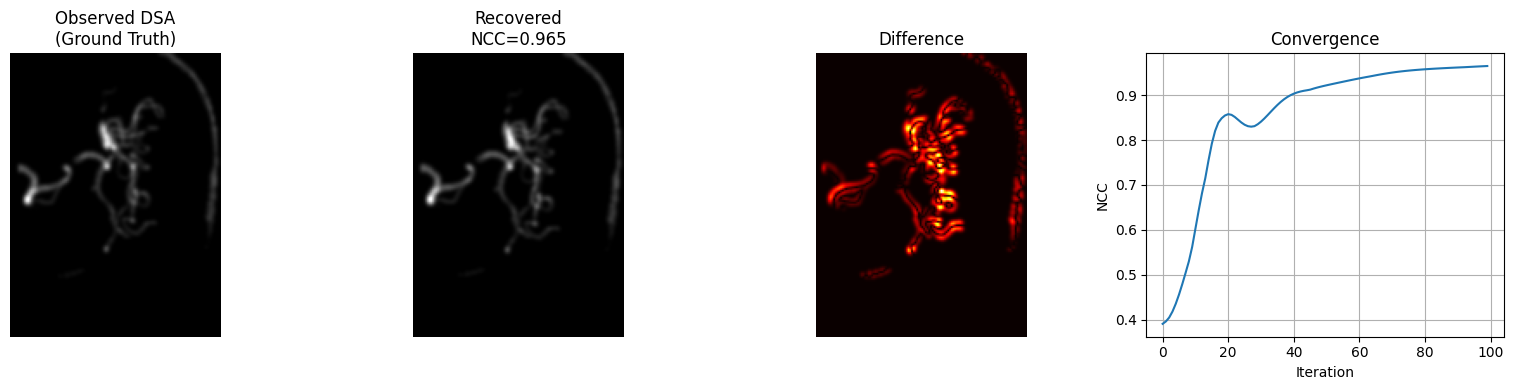

In [31]:
# =============================================================================
# Test DiffPose Registration on Baseline (new)
# =============================================================================

print("Running registration on baseline...")
print(f"Ground truth params: {T_gt}")

# First verify rendering matches
test_render = render_at_pose(healthy_binary_ds, T_gt, spacing_ds, PROJ_AXIS)
match_ncc = ncc_numpy(test_render, baseline_dsa_obs)
print(f"Verification - NCC between GT render and observed: {match_ncc:.6f}")
print("(Should be ~1.0 if rendering matches)")

baseline_problem = RegistrationProblem(
    moving_volume=healthy_binary_ds,
    observed_image=baseline_dsa_obs,
    spacing=spacing_ds,
    proj_axis=PROJ_AXIS,
)

baseline_reg = register_multistart(
    problem=baseline_problem,
    n_restarts=1,
    metric="ncc",
    optimizer_config=OptimizerConfig(n_iters=100),
    verbose=True,
)

baseline_err = summarize_pose_error(baseline_reg.pred_pose, T_gt)

print("\n" + "=" * 60)
print("BASELINE REGISTRATION RESULTS")
print("=" * 60)
print(f"GT params       : {T_gt}")
print(f"Recovered params: {baseline_reg.pred_pose.as_array()}")
print(f"Best NCC        : {baseline_reg.best_score:.4f}")
print(f"Rotation error (deg): {baseline_err['rot_err_deg_l2']:.4f}")
print(f"Translation error (mm): {baseline_err['trans_err_mm_l2']:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(baseline_dsa_obs, cmap="gray")
axes[0].set_title("Observed DSA\n(Ground Truth)")
axes[0].axis("off")

axes[1].imshow(baseline_reg.pred_image, cmap="gray")
axes[1].set_title(f"Recovered\nNCC={baseline_reg.best_score:.3f}")
axes[1].axis("off")

axes[2].imshow(np.abs(baseline_dsa_obs - baseline_reg.pred_image), cmap="hot")
axes[2].set_title("Difference")
axes[2].axis("off")

axes[3].plot(baseline_reg.score_history)
axes[3].set_xlabel("Iteration")
axes[3].set_ylabel("NCC")
axes[3].set_title("Convergence")
axes[3].grid(True)

plt.tight_layout()
plt.show()

# Run experiments

In [ ]:

# =============================================================================
# Benchmark Function (DiffPose-Style) using register_single_start
# =============================================================================

def run_benchmark_cases_single_start(case_dict, moving_model=None, init_params=None,
                        n_iters=150, verbose=False):
    """
    Run registration benchmark across multiple conditions.
    """
    if moving_model is None:
        moving_model = healthy_binary_ds

    rows = []
    preds = {}

    for case_name, observed_dsa in tqdm(case_dict.items(), desc="Benchmark"):
        problem = RegistrationProblem(
            moving_volume=moving_model,
            observed_image=observed_dsa,
            spacing=spacing_ds,
            proj_axis=PROJ_AXIS,
        )

        init_pose = None if init_params is None else PoseParams.from_array(init_params)

        reg = register_single_start(
            problem=problem,
            init_pose=init_pose,
            metric="ncc",
            optimizer_config=OptimizerConfig(n_iters=n_iters),
            verbose=False,
        )

        err = summarize_pose_error(reg.pred_pose, T_gt)

        rows.append({
            "case": str(case_name),
            "best_ncc": reg.best_score,
            "rot_err_deg_l2": err["rot_err_deg_l2"],
            "trans_err_mm_l2": err["trans_err_mm_l2"],
        })
        preds[str(case_name)] = reg

    return pd.DataFrame(rows), preds

**<font color='purple'> Benchmark Function using `multiscale_register` </font>**

In [35]:
# =============================================================================
# Benchmark Function (DiffPose-Style) using multiscale_register
# =============================================================================

def run_benchmark_cases(case_dict, moving_model=None, init_params=None,
                        n_iters=150, verbose=False, metric="ncc",
                        target_points_ijk=None):
    if moving_model is None:
        moving_model = healthy_binary_ds

    if target_points_ijk is None:
        target_points_ijk = sample_vessel_target_points(
            healthy_binary_ds, n_points=200, seed=42
        )

    rows = []
    preds = {}

    for case_name, observed_dsa in tqdm(case_dict.items(), desc="Benchmark"):
        problem = RegistrationProblem(
            moving_volume=moving_model,
            observed_image=observed_dsa,
            spacing=spacing_ds,
            proj_axis=PROJ_AXIS,
        )

        init_pose = None if init_params is None else PoseParams.from_array(init_params)

        # reg = register_single_start(
        #     problem=problem,
        #     init_pose=init_pose,
        #     metric=metric,
        #     optimizer_config=OptimizerConfig(n_iters=n_iters),
        #     verbose=False,
        # )
        reg = multiscale_register(
              problem=problem,
              metric=metric,
              verbose=False,
          )

        param_err = summarize_pose_error(reg.pred_pose, T_gt)
        mtre = compute_mtre(reg.pred_pose, T_gt, target_points_ijk, spacing_ds)

        rows.append({
            "case": str(case_name),
            "best_ncc": reg.best_score,
            "mTRE_mm": mtre["mTRE_mm"],
            "median_TRE_mm": mtre["median_TRE_mm"],
            "max_TRE_mm": mtre["max_TRE_mm"],
            "rot_err_deg_l2": param_err["rot_err_deg_l2"],
            "trans_err_mm_l2": param_err["trans_err_mm_l2"],
            "success_le_1mm": float(mtre["mTRE_mm"] <= 1.0),
        })
        preds[str(case_name)] = {
            "registration": reg,
            "param_error": param_err,
            "mtre": mtre,
        }

    df = pd.DataFrame(rows)
    return df, preds

In [ ]:
# =============================================================================
# Q1: Gaussian Noise Benchmark
# =============================================================================

print("Running Q1 Gaussian noise benchmark (DiffPose)...")

q1_gaussian_table, q1_gaussian_preds = run_benchmark_cases(
    {f"sigma_{sigma}": img for sigma, img in q1_gaussian_dsas.items()},
    #n_iters=3, #150
    verbose=False,
)

print("\nQ1 Gaussian Noise Results:")
print(q1_gaussian_table.to_string(index=False))
q1_gaussian_table

Running Q1 Gaussian noise benchmark (DiffPose)...


Benchmark: 100%|██████████| 5/5 [01:30<00:00, 18.07s/it]


Q1 Gaussian Noise Results:
      case  best_ncc  rot_err_deg_l2  trans_err_mm_l2
 sigma_0.0  0.406619        4.545704         6.449033
sigma_0.01  0.400463        4.545708         6.449214
sigma_0.03  0.380615        4.545901         6.452226
sigma_0.05  0.352717        4.546283         6.458170
 sigma_0.1  0.270630        4.547718         6.477435


,case,best_ncc,rot_err_deg_l2,trans_err_mm_l2
0,sigma_0.0,0.406619,4.545704,6.449033
1,sigma_0.01,0.400463,4.545708,6.449214
2,sigma_0.03,0.380615,4.545901,6.452226
3,sigma_0.05,0.352717,4.546283,6.458170
4,sigma_0.1,0.270630,4.547718,6.477435


In [ ]:
# =============================================================================
# Q2: Volume Loss Benchmark
# =============================================================================

print("Running Q2 volume loss benchmark (DiffPose)...")

q2_table, q2_preds = run_benchmark_cases(
    {f"loss_{int(frac*100):03d}": img for frac, img in q2_dsas_obs.items()},
    #n_iters=3,
    verbose=False,
)

print("\nQ2 Volume Loss Results:")
print(q2_table.to_string(index=False))
q2_table

Running Q2 volume loss benchmark (DiffPose)...


Benchmark: 100%|██████████| 5/5 [01:26<00:00, 17.39s/it]


Q2 Volume Loss Results:
    case  best_ncc  rot_err_deg_l2  trans_err_mm_l2
loss_000  0.406619        4.545704         6.449033
loss_010  0.404521        4.545490         6.447703
loss_025  0.403799        4.545606         6.448227
loss_050  0.399765        4.546176         6.451471
loss_100  0.000000        4.553902         6.556393


,case,best_ncc,rot_err_deg_l2,trans_err_mm_l2
0,loss_000,0.406619,4.545704,6.449033
1,loss_010,0.404521,4.545490,6.447703
2,loss_025,0.403799,4.545606,6.448227
3,loss_050,0.399765,4.546176,6.451471
4,loss_100,0.000000,4.553902,6.556393


In [41]:
# =============================================================================
# Q3: Vessel Group Removal Benchmark
# =============================================================================

print("Running Q3 vessel group removal benchmark (DiffPose)...")

q3_table, q3_preds = run_benchmark_cases(
    q3_dsas_obs,
    #n_iters=3,
    verbose=False,
)

print("\nQ3 Vessel Group Removal Results:")
print(q3_table.to_string(index=False))
q3_table

Running Q3 vessel group removal benchmark (DiffPose)...


Benchmark: 100%|██████████| 4/4 [30:34<00:00, 458.54s/it]


Q3 Vessel Group Removal Results:
    case  best_ncc  mTRE_mm  median_TRE_mm  max_TRE_mm  rot_err_deg_l2  trans_err_mm_l2  success_le_1mm
baseline  0.984057 2.243608       2.357395    3.744487        2.384638         2.102534             0.0
proximal  0.773007 2.435132       2.467394    3.542804        2.340223         2.065922             0.0
  medium  0.926771 2.548729       2.701792    4.038042        2.344078         2.154038             0.0
  distal  0.906161 2.717173       2.574463    4.952361        3.167969         2.029246             0.0


,case,best_ncc,mTRE_mm,median_TRE_mm,max_TRE_mm,rot_err_deg_l2,trans_err_mm_l2,success_le_1mm
0,baseline,0.984057,2.243608,2.357395,3.744487,2.384638,2.102534,0.0
1,proximal,0.773007,2.435132,2.467394,3.542804,2.340223,2.065922,0.0
2,medium,0.926771,2.548729,2.701792,4.038042,2.344078,2.154038,0.0
3,distal,0.906161,2.717173,2.574463,4.952361,3.167969,2.029246,0.0


In [ ]:
# =============================================================================
# Summary Results
# =============================================================================

print("="*70)
print("BENCHMARK SUMMARY - DiffPose Registration")
print("="*70)

print("\n" + "-"*70)
print("Q1: Gaussian Noise (noise added after projection)")
print("-"*70)
print(q1_gaussian_table.to_string(index=False))

print("\n" + "-"*70)
print("Q2: Random Vessel Volume Loss")
print("-"*70)
print(q2_table.to_string(index=False))

print("\n" + "-"*70)
print("Q3: Vessel Group Removal (proximal/medium/distal)")
print("-"*70)
print(q3_table.to_string(index=False))

print("\n" + "="*70)
print(f"Ground Truth Pose: {T_gt}")
print("="*70)

# Combine all results
all_results = pd.concat([
    q1_gaussian_table.assign(experiment='Q1_gaussian'),
    q2_table.assign(experiment='Q2_volume_loss'),
    q3_table.assign(experiment='Q3_group_removal'),
])

# Save to CSV
output_csv = OUT_DIR / 'diffpose_registration_results.csv'
all_results.to_csv(output_csv, index=False)
print(f"\nResults saved to {output_csv}")

BENCHMARK SUMMARY - DiffPose Registration

----------------------------------------------------------------------
Q1: Gaussian Noise (noise added after projection)
----------------------------------------------------------------------
      case  best_ncc  rot_err_deg_l2  trans_err_mm_l2
 sigma_0.0  0.406619        4.545704         6.449033
sigma_0.01  0.400463        4.545708         6.449214
sigma_0.03  0.380615        4.545901         6.452226
sigma_0.05  0.352717        4.546283         6.458170
 sigma_0.1  0.270630        4.547718         6.477435

----------------------------------------------------------------------
Q2: Random Vessel Volume Loss
----------------------------------------------------------------------
    case  best_ncc  rot_err_deg_l2  trans_err_mm_l2
loss_000  0.406619        4.545704         6.449033
loss_010  0.404521        4.545490         6.447703
loss_025  0.403799        4.545606         6.448227
loss_050  0.399765        4.546176         6.451471
loss_100

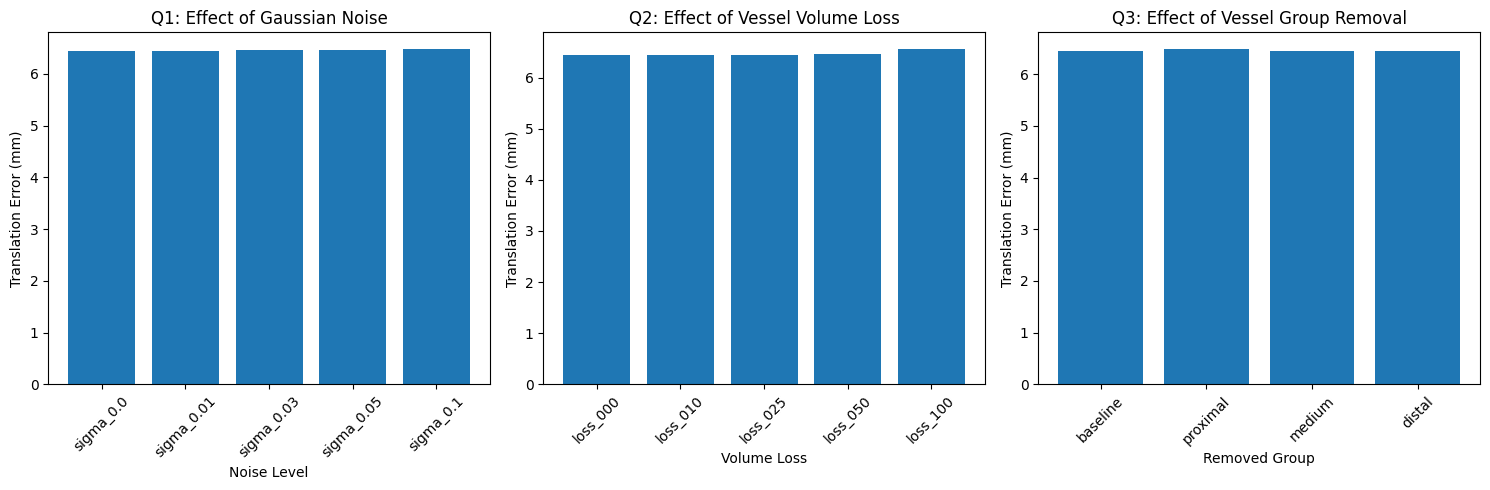

Figure saved to /content/drive/MyDrive/CSE291G/output/cse291_project_outputs_complete/registration_errors_diffpose.png


In [ ]:
# =============================================================================
# Visualization: Registration Error vs Condition
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Q1: Noise
ax = axes[0]
ax.bar(q1_gaussian_table['case'], q1_gaussian_table['trans_err_mm_l2'])
ax.set_xlabel('Noise Level')
ax.set_ylabel('Translation Error (mm)')
ax.set_title('Q1: Effect of Gaussian Noise')
ax.tick_params(axis='x', rotation=45)

# Q2: Volume Loss
ax = axes[1]
ax.bar(q2_table['case'], q2_table['trans_err_mm_l2'])
ax.set_xlabel('Volume Loss')
ax.set_ylabel('Translation Error (mm)')
ax.set_title('Q2: Effect of Vessel Volume Loss')
ax.tick_params(axis='x', rotation=45)

# Q3: Group Removal
ax = axes[2]
ax.bar(q3_table['case'], q3_table['trans_err_mm_l2'])
ax.set_xlabel('Removed Group')
ax.set_ylabel('Translation Error (mm)')
ax.set_title('Q3: Effect of Vessel Group Removal')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUT_DIR / 'registration_errors_diffpose.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to {OUT_DIR / 'registration_errors_diffpose.png'}")